# Simulating Rubin DP2 with LightCurveLynx

This notebook demonstrates how to simulate multiple types of variable events using [LightCurveLynx](https://lightcurvelynx.readthedocs.io/) for (still unreleased) Rubin Data Preview 2 (DP2).

We are using an available visit table for the Science Validation program, covering LSSTCam observations before the end of September 2025. See also [this documentation page for simulating Rubin data previews and releases](https://lightcurvelynx.readthedocs.io/en/latest/notebooks/pre_executed/rubin_ccdvisit.html).

2025.03.04, Konstantin Malanchev (<malanchev@cmu.edu>) and LightCurveLynx team. Based on LightCurveLynx v0.3.2, please check actual documentation if using a newer version.

### 1. Setting Things Up

Install packages, downloading visit table, import modules.

In [1]:
# # Uncomment to install dependencies
# %pip install lightcurvelynx pyLIMA sncosmo redback

In [2]:
# Set Science Validation visit table filename
VISITS_DB = "lsstcam_20250930.db"

In [3]:
# # Uncomment to download the science validation visit table
# import requests

# VISITS_DB_URL = "https://s3df.slac.stanford.edu/data/rubin/sim-data/sv/sv_progress_databases/lsstcam_20250930/lsstcam_20250930.db"
# data = requests.get(VISITS_DB_URL).content
# with open(VISITS_DB, "wb") as fh:
#     fh.write(data)
# del data

In [4]:
# Import Python modules

import matplotlib.pyplot as plt  # for plotting
import redback  # for kilonova model implementation

from scipy.interpolate import interp1d  # for SN Ia redshift distribution

# Parameter distributions
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc  # numpy.random-based distributions
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler  # sky position
from lightcurvelynx.math_nodes.scipy_random import SamplePDF  # sample values from random variable's PDF

# Model classes
from lightcurvelynx.models.pylima_models import PyLIMAWrapperModel  # star micro-lensing with pyLIMA
from lightcurvelynx.models.redback_models import RedbackWrapperModel  # kilonova with Redback
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel  # SN Ia with sncosmo
from lightcurvelynx.models.snia_host import SNIaHost  # host galaxy model for SN Ia

# Survey and passbands
from lightcurvelynx.astro_utils.passbands import PassbandGroup  # Transmissions of photometric passbands
from lightcurvelynx.obstable.lsst_obstable import LSSTObsTable  # Survey class

# Simulations and plotting
from lightcurvelynx.simulate import simulate_lightcurves  # pipeline runner function
from lightcurvelynx.utils.plotting import plot_lightcurves

# Utilities
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    HostmassX1Func,
    X0FromDistMod,
    num_snia_per_redshift_bin,
)  # SN Ia SALT2 model parameter helpers
from lightcurvelynx.utils.extrapolate import LinearDecayOnMag, ZeroPadding  # temp-SED extrapolation modes
from lightcurvelynx.utils.io_utils import read_sqlite_table  # to read visits table

No module named 'lalsimulation'
lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model
swifttools not available. You will not be able to download Swift afterglow data via API.
10:18 bilby INFO    : Running bilby version: 2.8.0
10:18 redback INFO    : Running redback version: unknown


### 2. Define Survey and Passbands

Load visit table into a `ObsTable` object, inistailize `Passbands`.

Loaded 20436 observations from lsstcam_20250930.db


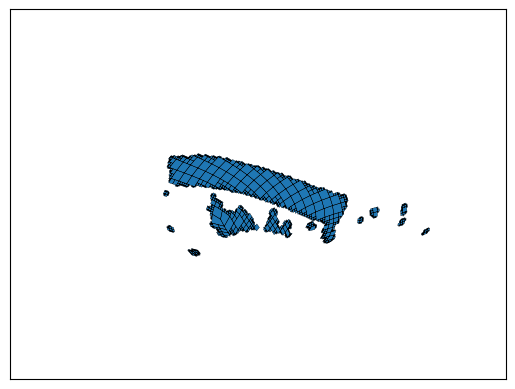

In [5]:
# Create ObsTable, which describes survey visits and noise properties

table = read_sqlite_table(VISITS_DB, sql_query="SELECT * FROM observations")
obs_table = LSSTObsTable.from_sv_visits_table(table)

print(f"Loaded {len(obs_table)} observations from {VISITS_DB}")

obs_table.plot_footprint()

In [6]:
# Create RA and Dec parameter distributions using the ObsTable instance
# For simplicity we will reuse the same distributions for all the models
radec_node = ObsTableUniformRADECSampler(obs_table, node_label="radec")
ra_sampler = radec_node.ra
dec_sampler = radec_node.dec

In [7]:
# Also create reference time parameter distribution (usually close to the peak or to the explosure).
# We make it to be with the survey time span
mjd_start, mjd_end = obs_table.time_bounds()
t0_sampler = NumpyRandomFunc("uniform", low=mjd_start, high=mjd_end)

Loaded Passbands: PassbandGroup containing 6 passbands: LSST_u, LSST_g, LSST_r, LSST_i, LSST_z, LSST_y


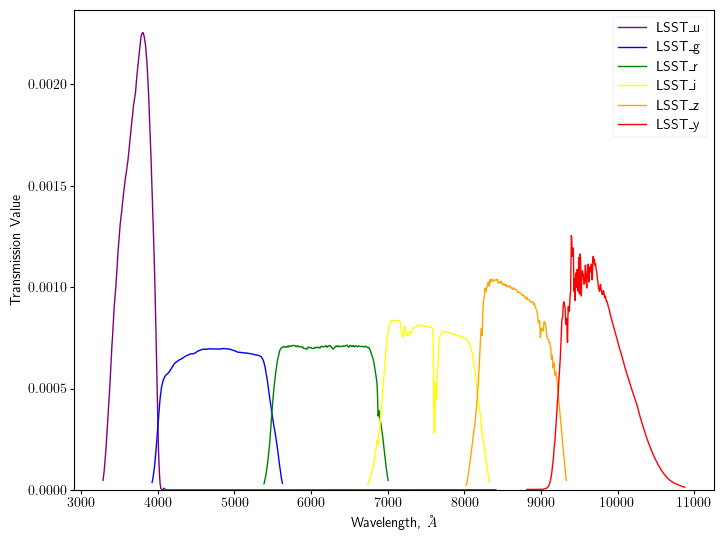

In [8]:
# Load LSDB passband profiles. Plot shows normalized system transmission in 1/Angrstrom.

passband_group = PassbandGroup.from_preset(preset="LSST")
print(f"Loaded Passbands: {passband_group}")
passband_group.plot()

### 3. Define Variability models

Create few oversimplified models to simulate

#### 3.1 Microlensing event with pyLIMA

See [this LightCurveLynx — pyLIMA integration notebook](https://lightcurvelynx.readthedocs.io/en/latest/notebooks/pre_executed/pylima_example.html) for a more detailed example.
Also please refer to [the pyLIMA repository](https://github.com/ebachelet/pyLIMA) for more information on the package.

In [9]:
# Set model parameters

# Use a fixed piEN and piEE and random values for u0 and tE
pylima_params = {
    "u0": NumpyRandomFunc("uniform", low=0.01, high=0.1),
    "tE": NumpyRandomFunc("uniform", low=20.0, high=30.0),
    "piEN": 0.1,
    "piEE": 0.1,
}

# Both the source and blend amounts are specified as magnitudes in each filter.
# LightCurveLynx handles both the conversion from magnitudes to fluxes and
# the addition of the correct parameter prefix.
source_mags = {
    "u": NumpyRandomFunc("normal", loc=22.5, scale=0.3),
    "g": NumpyRandomFunc("normal", loc=22.0, scale=0.3),
    "r": NumpyRandomFunc("normal", loc=21.5, scale=0.3),
    "i": NumpyRandomFunc("normal", loc=21.2, scale=0.3),
    "z": NumpyRandomFunc("normal", loc=21.5, scale=0.3),
    "y": NumpyRandomFunc("normal", loc=22.0, scale=0.3),
}
# Just fixed values
blend_mags = {
    "u": 24.0,
    "g": 23.5,
    "r": 23.0,
    "i": 22.8,
    "z": 23.0,
    "y": 23.2,
}

In [10]:
# Initialize the model

pylima_model = PyLIMAWrapperModel(
    "PSPL",  # Model type
    source_mags=source_mags,  # Dictionary of filter to a magnitude distribution
    blend_mags=blend_mags,  # Dictionary of filter to a magnitude values
    ra=ra_sampler,  # Sample RA from uniform distribution
    dec=dec_sampler,  # Sample Dec from uniform distribution
    t0=t0_sampler,  # Sample t0 from uniform distribution
    parallax_model="Full",  # Use full parallax model
    pylima_params=pylima_params,  # Additional PyLIMA parameters
    node_label="source",  # A node name for convenience
)

### 3.2 SN Ia with sncosmo

We are going to simulate Supernova type Ia using SALT2 model from [sncosmo](https://sncosmo.readthedocs.io) package.

In [11]:
# Set model parameters

# Set host galaxy redshift distribution
zmin = 0.001
zmax = 0.8
H0 = 70.0
Omega_m = 0.3
nsn, z = num_snia_per_redshift_bin(zmin, zmax, 100, H0=H0, Omega_m=Omega_m)
zpdf = interp1d(z, nsn, bounds_error=False, fill_value=0)

# Host galaxy model
host = SNIaHost(
    ra = radec_node.ra,
    dec = radec_node.dec,
    hostmass=10.,
    redshift=SamplePDF(zpdf),
    node_label="host",
)

# Distance is derived from a cosmology model
distmod_func = DistModFromRedshift(host.redshift, H0=H0, Omega_m=Omega_m)

# SALT-specific parameters
x1_func = NumpyRandomFunc("normal", loc=0, scale=0.2)
c_func = NumpyRandomFunc("normal", loc=0, scale=0.02)
m_abs_func = NumpyRandomFunc("normal", loc=-19., scale=0.1)
x0_func = X0FromDistMod(
    distmod=distmod_func,
    x1=x1_func,
    c=c_func,
    alpha=0.14,
    beta=3.1,
    m_abs=m_abs_func,
    node_label="x0_func",
)

# Shift supernova from the host galaxy center
ra_ia = NumpyRandomFunc("normal", loc=host.ra, scale=0.01)
dec_ia = NumpyRandomFunc("normal", loc=host.dec, scale=0.01)

In [12]:
# Initialize the model with temporal-SED extrapolation

# Temporal and spectral extraploation
time_extrap_before = ZeroPadding()
time_extrap_after = LinearDecayOnMag(decay_rate=0.02, mag_thres=40.)
wave_extrap_before = ZeroPadding()
wave_extrap_after = ZeroPadding()

snia_model = SncosmoWrapperModel(
    "salt2-h17",  # sncosmo model name
    t0=t0_sampler,
    x0=x0_func,
    x1=x1_func,
    c=c_func,
    ra=ra_ia,
    dec=dec_ia,
    time_extrapolation=(time_extrap_before, time_extrap_after),
    wave_extrapolation=(wave_extrap_before, wave_extrap_after),
    redshift=host.redshift,
    node_label="source",
)

#### 3.3 Kilonova with Redback

See [this LightCurveLynx — Redback integration notebook](https://lightcurvelynx.readthedocs.io/en/latest/notebooks/pre_executed/redback_example.html) for a more detailed example.
Also please refer to [the Redback documentation](https://redback.readthedocs.io/).

In [13]:
# Set the parameters that are needed by the redback model. Note that the first two are set
# from samplers, while the last three are fixed values.

mej_sampler = NumpyRandomFunc("normal", loc=0.05, scale=0.02)
redshift_sampler = NumpyRandomFunc("uniform", low=0.01, high=0.1)

redback_parameters = {
    "mej": mej_sampler,
    "redshift": redshift_sampler,
    "temperature_floor": 3000,
    "kappa": 1,
    "vej": 0.2,
}

In [14]:
# Initialize the model

# Select redback model first
redback_model_fn = redback.model_library.all_models_dict["one_component_kilonova_model"]

kilonova_model = RedbackWrapperModel(
    redback_model_fn,
    parameters=redback_parameters,  # Set ALL the redback model parameters
    ra=ra_sampler,
    dec=dec_sampler,
    t0=t0_sampler,
    node_label="source",
)

### 4. Run simulations and plot light curves  

Simulate 100 objects for each model and plot one light curve per model.  
Check ["Parallel Computation"](https://lightcurvelynx.readthedocs.io/en/latest/notebooks/parallel_runs.html) documentation page for larger simulations.

In [15]:
# Set number of simulations
N_SIMS = 100

In [16]:
# Run simulations, save results as a list of data-frames

dfs = []
for i, model in enumerate([pylima_model, snia_model, kilonova_model]):
    # Set different random seed so we get different coordinates and other parameters
    %time df = simulate_lightcurves(model, N_SIMS, obs_table, passband_group, rng=np.random.default_rng(i+1))
    dfs.append(df)

Simulating: 100%|████████████████████████████| 100/100 [00:04<00:00, 21.73obj/s]


CPU times: user 4.55 s, sys: 79 ms, total: 4.63 s
Wall time: 4.64 s


Simulating: 100%|███████████████████████████| 100/100 [00:00<00:00, 859.43obj/s]


CPU times: user 130 ms, sys: 3.29 ms, total: 133 ms
Wall time: 133 ms


Simulating:   0%|                                      | 0/100 [00:00<?, ?obj/s]/Users/hombit/.virtualenvs/dp2-lynx/lib/python3.14/site-packages/scipy/integrate/_quadrature.py:336: RuntimeWarning: overflow encountered in multiply
  res = xp.cumulative_sum(d * (y[slice1] + y[slice2]) / 2.0, axis=axis)
/Users/hombit/.virtualenvs/dp2-lynx/lib/python3.14/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/hombit/.virtualenvs/dp2-lynx/lib/python3.14/site-packages/redback/transient_models/kilonova_models.py:1741: RuntimeWarning: overflow encountered in multiply
  integrand = lum_in * e_th * (time/tdiff) * np.exp(time**2/tdiff**2)
Simulating:  10%|██▉                          | 10/100 [00:00<00:00, 99.30obj/s]/Users/hombit/.virtualenvs/dp2-lynx/lib/python3.14/site-packages/redback/transient_models/kilonova_models.py:1741: RuntimeWarning: overflow encountered in exp
  in

CPU times: user 1.49 s, sys: 10.9 ms, total: 1.5 s
Wall time: 1.5 s


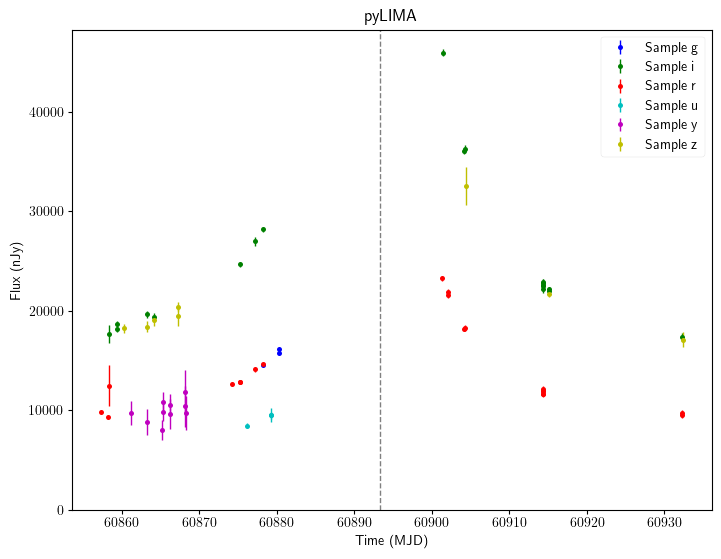

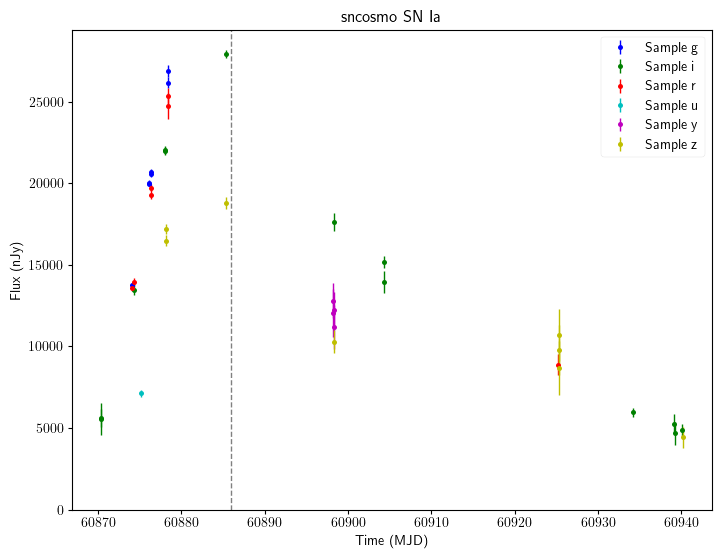

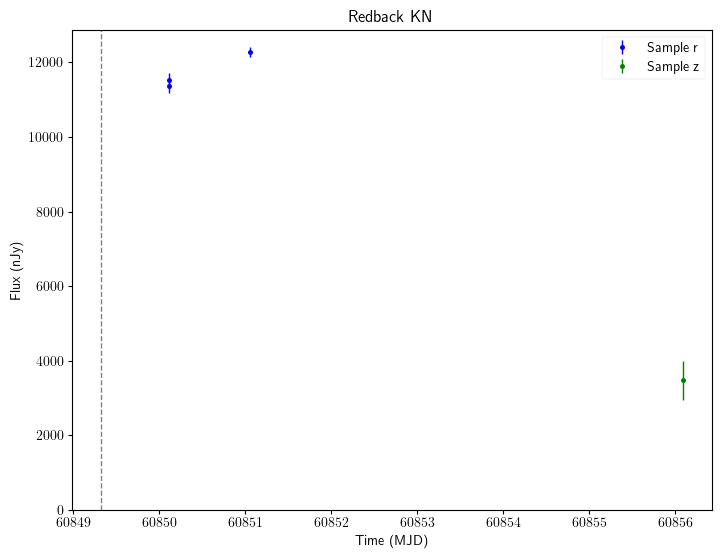

In [17]:
# Plot a high-s/n ratio light curve for each model
# Dashed line is t0

# Minimum S/N ratio to select light curve
S2N_MIN = 50.0

# Iterate over results
for name, df in zip(["pyLIMA", "sncosmo SN Ia", "Redback KN"], dfs):
    # First, select highest s/n
    s2n_max = df.map_rows(lambda row: np.max(row["lightcurve.flux"] / row["lightcurve.fluxerr"]))
    # Second, select light curve with s/n near the peak closes to 10
    lc_idx = np.where(s2n_max > S2N_MIN)[0][0]
    lc = df.iloc[lc_idx]["lightcurve"]
    # Third, filter non-detections out
    lc = lc[lc["flux"] / lc["fluxerr"] >= 5.0]
    _ = plot_lightcurves(
        times=lc["mjd"],
        fluxes=lc["flux"],
        fluxerrs=lc["fluxerr"],
        filters=lc["filter"],
    )
    plt.title(name)
    plt.ylim([0, None])
    plt.axvline(df.iloc[lc_idx]["params"]["source.t0"], ls='--', color='grey')
    plt.gca().relim()
    plt.gca().autoscale_view()